# Regressão Linear Multivariada
## Previsão do Valor de Empréstimo Pessoal Aprovado

Neste notebook, construiremos um modelo de regressão linear com **múltiplas variáveis de entrada** para prever o valor de empréstimo pessoal que um banco aprova para seus clientes.

O modelo segue a forma: **y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ**

## 1. Importação das Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 300 registros de clientes de um banco, com diversas características pessoais e financeiras, além do valor de empréstimo pessoal aprovado.

In [3]:
df = pd.read_csv('dados_emprestimo_pessoal.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 300 linhas × 7 colunas


,renda_mensal,idade,tempo_emprego_anos,score_credito,divida_atual,num_dependentes,valor_emprestimo_aprovado
0,6849.65,60,18.7,306,35234.04,4,34253.82
1,14147.85,43,11.3,432,10092.67,2,61516.63
2,13158.13,47,25.1,330,33671.62,2,38730.88
3,19243.80,65,17.6,834,48495.60,3,90985.79
4,19782.62,46,8.8,725,4695.04,5,90732.14
5,3268.51,38,21.4,693,33630.11,5,48932.31
6,12489.15,34,15.8,662,22187.51,4,65108.26
7,19524.08,41,16.0,736,43407.11,4,69105.70
8,16087.82,46,14.4,850,8857.49,5,97968.48
9,25981.72,25,14.9,381,34631.30,4,61998.00


In [4]:
df.describe().round(2)

,renda_mensal,idade,tempo_emprego_anos,score_credito,divida_atual,num_dependentes,valor_emprestimo_aprovado
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,16065.11,43.72,15.75,572.42,25267.16,2.59,71205.11
std,8450.72,12.94,8.74,159.93,14275.97,1.70,20017.18
min,2303.45,22.00,0.00,300.00,287.93,0.00,22114.53
25%,8643.56,32.00,8.38,431.25,12664.63,1.00,56967.82
50%,16091.75,45.00,15.90,579.00,26001.00,3.00,71158.18
75%,23554.96,55.00,23.12,697.00,36295.84,4.00,87189.21
max,29992.09,65.00,30.00,850.00,49970.69,5.00,117928.65


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   renda_mensal               300 non-null    float64
 1   idade                      300 non-null    int64  
 2   tempo_emprego_anos         300 non-null    float64
 3   score_credito              300 non-null    int64  
 4   divida_atual               300 non-null    float64
 5   num_dependentes            300 non-null    int64  
 6   valor_emprestimo_aprovado  300 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 16.5 KB


## 3. Análise Exploratória

### 3.1 Distribuição das Variáveis

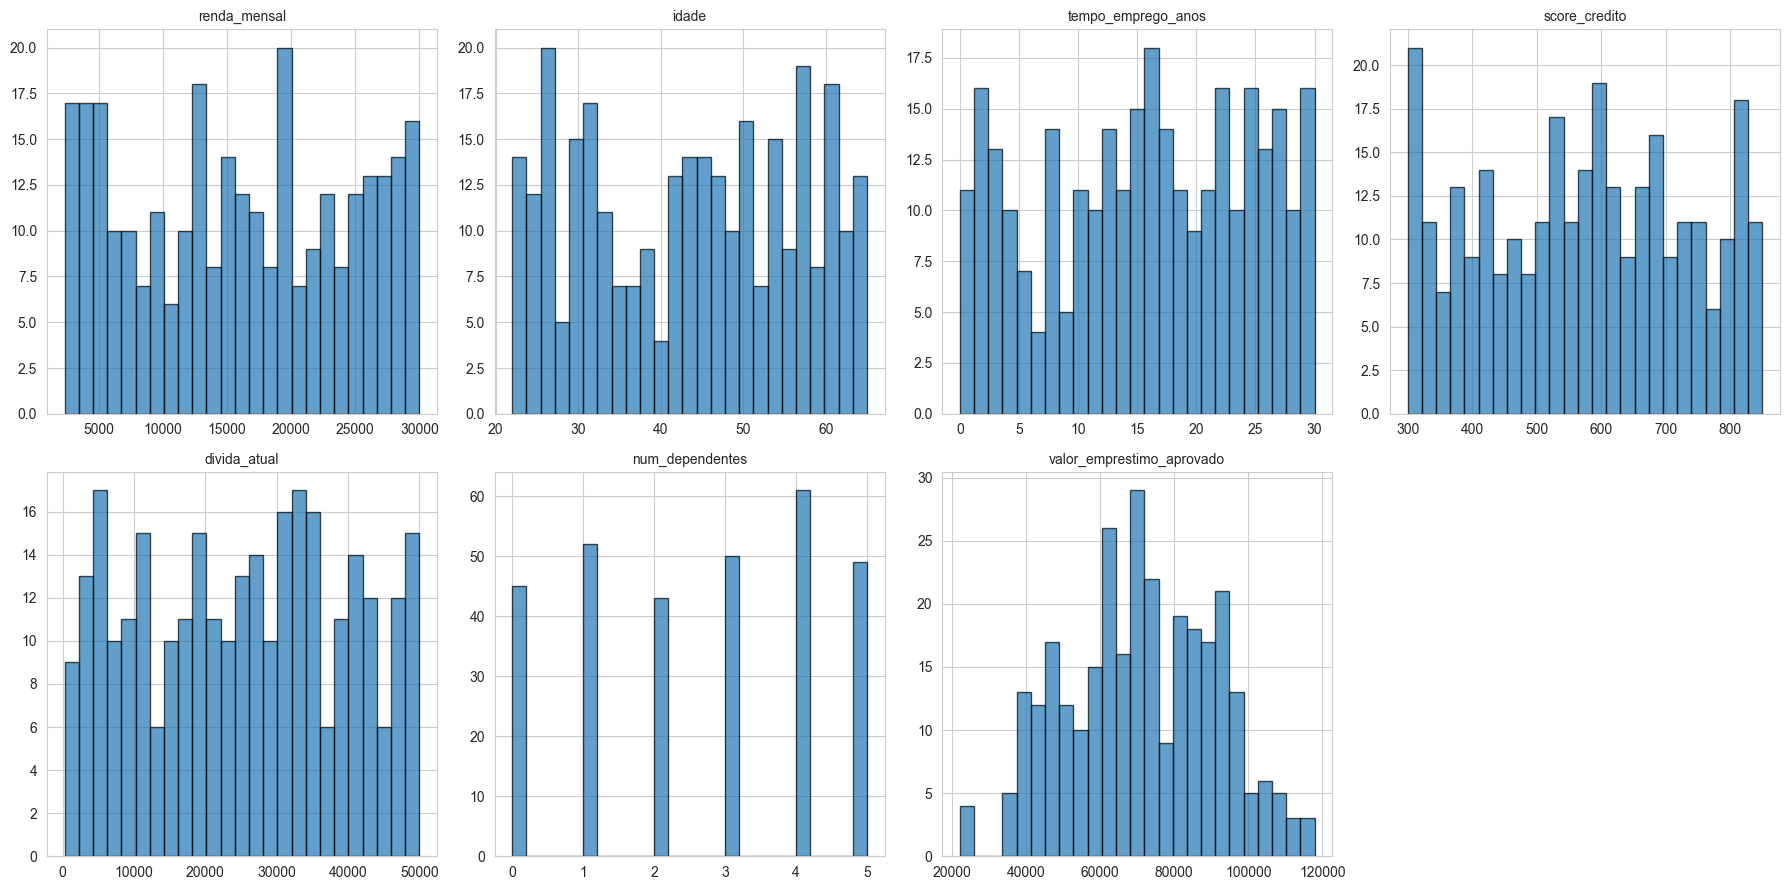

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)

# esconder eixo extra
if len(df.columns) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Matriz de Correlação

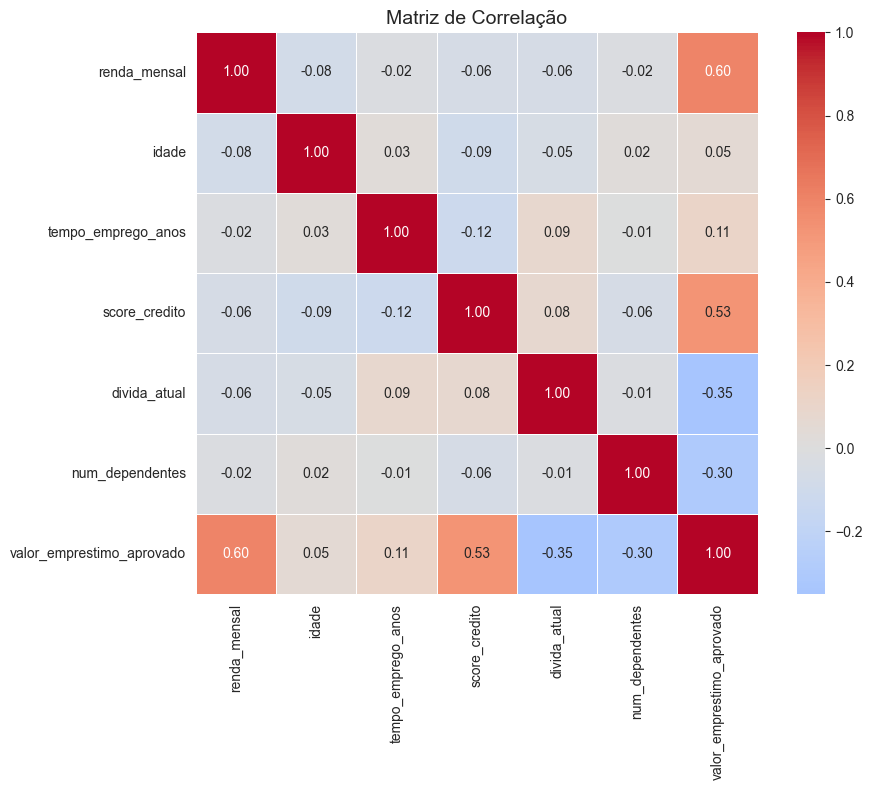

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Correlação com a Variável Alvo

In [8]:
corr_alvo = df.corr()['valor_emprestimo_aprovado'].drop('valor_emprestimo_aprovado').sort_values(ascending=False)
print('Correlação de cada variável com o valor do empréstimo aprovado:\n')
for var, corr in corr_alvo.items():
    print(f'  {var:<25s} {corr:>+.4f}')

Correlação de cada variável com o valor do empréstimo aprovado:

  renda_mensal              +0.5980
  score_credito             +0.5261
  tempo_emprego_anos        +0.1124
  idade                     +0.0540
  num_dependentes           -0.2970
  divida_atual              -0.3508


## 4. Preparação dos Dados

In [9]:
X = df.drop(columns='valor_emprestimo_aprovado')
y = df['valor_emprestimo_aprovado']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 240 amostras
Teste:  60 amostras


## 5. Treinamento do Modelo

In [10]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print(f'Intercepto (b₀): {modelo.intercept_:.2f}\n')
print('Coeficientes:')
for nome, coef in zip(X.columns, modelo.coef_):
    print(f'  {nome:<25s} {coef:>+12.4f}')

Intercepto (b₀): 7179.71

Coeficientes:
  renda_mensal                   +1.4890
  idade                        +211.2116
  tempo_emprego_anos           +486.9637
  score_credito                 +77.6531
  divida_atual                   -0.5261
  num_dependentes             -3047.9493


## 6. Interpretação dos Coeficientes

Cada coeficiente indica o impacto de uma variável no valor do empréstimo aprovado, **mantendo todas as outras variáveis constantes**.

- Coeficientes **positivos**: a variável contribui para aumentar o valor aprovado.
- Coeficientes **negativos**: a variável contribui para diminuir o valor aprovado.

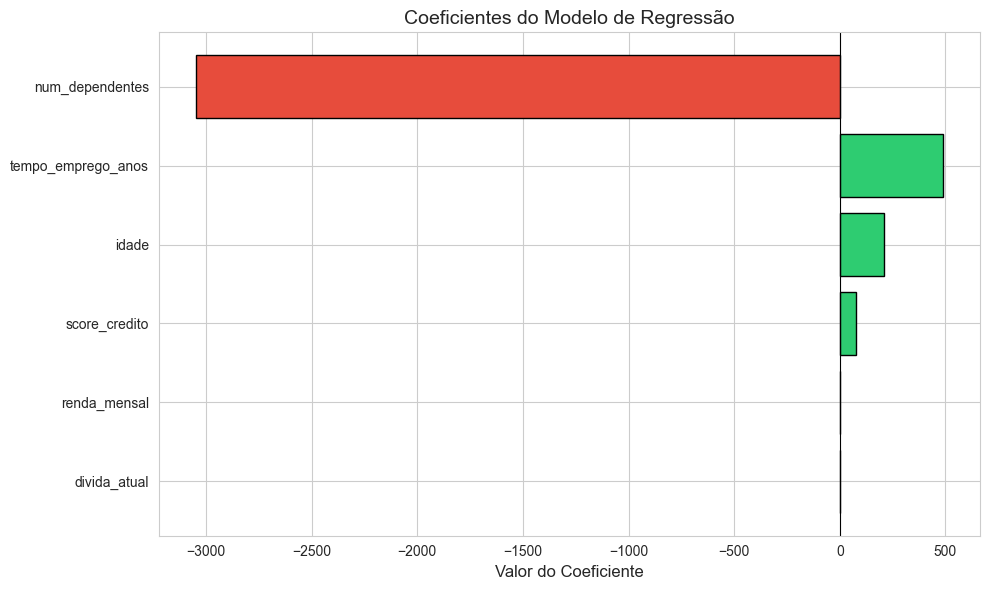

In [11]:
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
cores = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variável'], coef_df['Coeficiente'], color=cores, edgecolor='black')
plt.xlabel('Valor do Coeficiente', fontsize=12)
plt.title('Coeficientes do Modelo de Regressão', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Atenção:** para comparar a importância relativa das variáveis de forma justa, precisamos considerar as escalas de cada variável. Vamos padronizar os dados e retreinar.

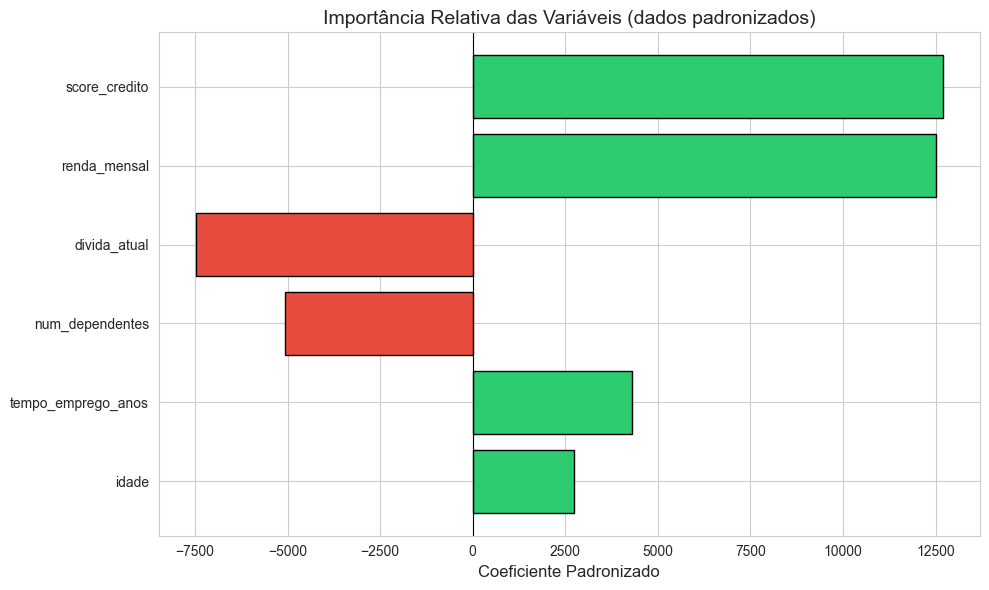

In [12]:
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

modelo_scaled = LinearRegression()
modelo_scaled.fit(X_treino_scaled, y_treino)

coef_scaled_df = pd.DataFrame({
    'Variável': X.columns,
    'Coef. Padronizado': modelo_scaled.coef_
}).sort_values('Coef. Padronizado', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
cores = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_scaled_df['Coef. Padronizado']]
plt.barh(coef_scaled_df['Variável'], coef_scaled_df['Coef. Padronizado'], color=cores, edgecolor='black')
plt.xlabel('Coeficiente Padronizado', fontsize=12)
plt.title('Importância Relativa das Variáveis (dados padronizados)', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Previsões no Conjunto de Teste

In [13]:
y_pred = modelo.predict(X_teste)

comparacao = pd.DataFrame({
    'Real (R$)': y_teste.values,
    'Previsto (R$)': y_pred.round(2),
    'Erro (R$)': (y_teste.values - y_pred).round(2)
})
comparacao.head(10)

,Real (R$),Previsto (R$),Erro (R$)
0,56480.33,46219.60,10260.73
1,71626.09,74350.87,-2724.78
2,76159.18,71739.49,4419.69
3,61998.00,57576.75,4421.25
4,61611.37,64544.20,-2932.83
5,91444.46,91603.65,-159.19
6,58730.95,56271.90,2459.05
7,71665.90,75938.49,-4272.59
8,48932.31,51373.40,-2441.09
9,63258.86,65567.38,-2308.52


## 8. Avaliação do Modelo

In [15]:
r2 = r2_score(y_teste, y_pred)
mae = mean_absolute_error(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
rmse = np.sqrt(mse)

print('╔══════════════════════════════════════╗')
print('║      MÉTRICAS DE AVALIAÇÃO           ║')
print('╠══════════════════════════════════════╣')
print(f'║  R²:    {r2:.4f}                       ║')
print(f'║  MAE:   R$ {mae:>10,.2f}                ║')
print(f'║  MSE:   {mse:>14,.2f}               ║')
print(f'║  RMSE:  R$ {rmse:>10,.2f}                ║')
print('╚══════════════════════════════════════╝')

╔══════════════════════════════════════╗
║      MÉTRICAS DE AVALIAÇÃO           ║
╠══════════════════════════════════════╣
║  R²:    0.9311                       ║
║  MAE:   R$   4,342.47                ║
║  MSE:    28,434,635.64               ║
║  RMSE:  R$   5,332.41                ║
╚══════════════════════════════════════╝


## 9. Valores Reais vs Previstos

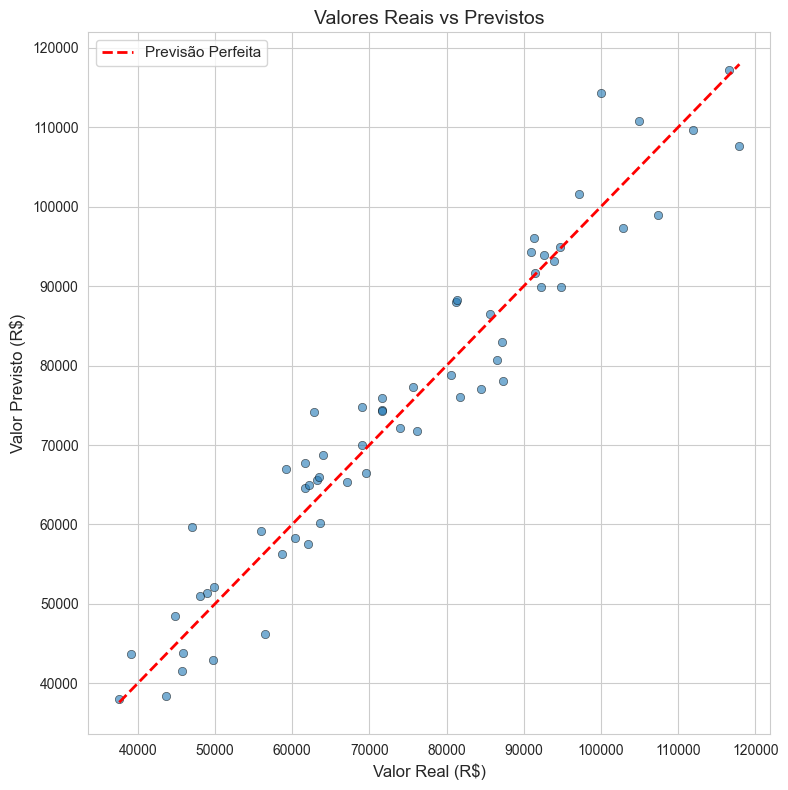

In [16]:
plt.figure(figsize=(8, 8))
plt.scatter(y_teste, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)

# Linha de referência (previsão perfeita)
lims = [min(y_teste.min(), y_pred.min()), max(y_teste.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Previsão Perfeita')

plt.xlabel('Valor Real (R$)', fontsize=12)
plt.ylabel('Valor Previsto (R$)', fontsize=12)
plt.title('Valores Reais vs Previstos', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Análise de Resíduos

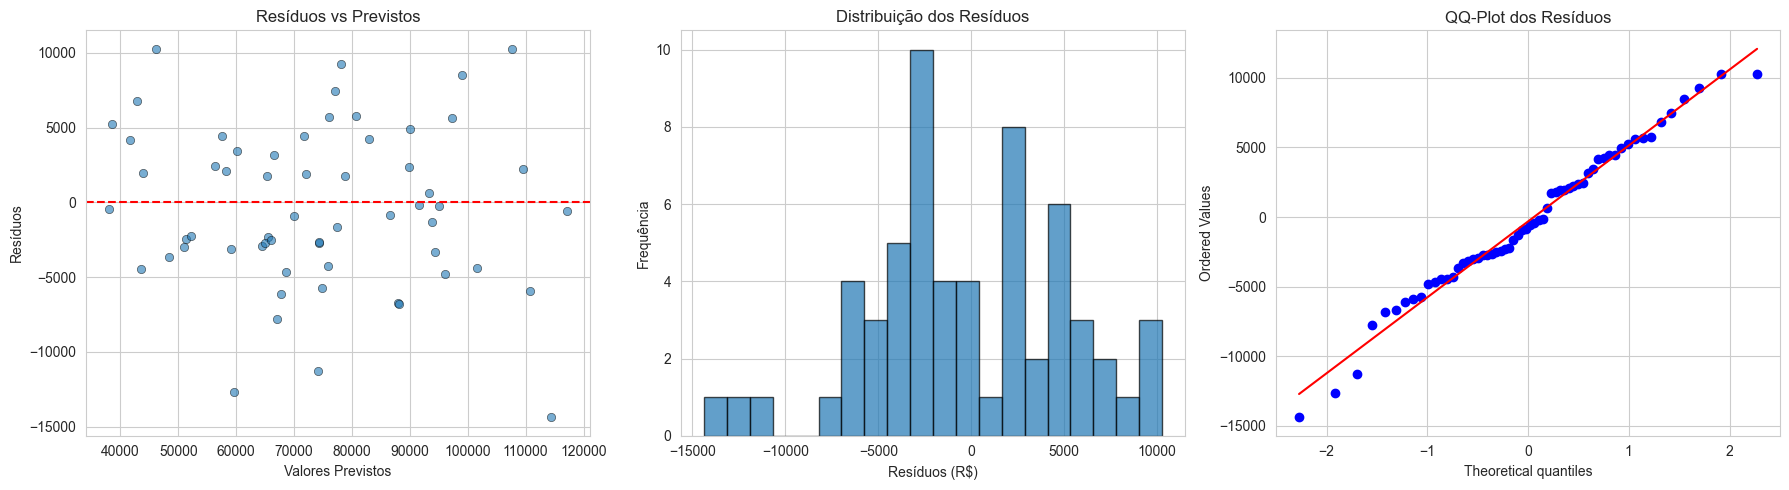

In [17]:
residuos = y_teste - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Resíduos vs Previstos
axes[0].scatter(y_pred, residuos, alpha=0.6, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Previstos')
axes[0].set_ylabel('Resíduos')
axes[0].set_title('Resíduos vs Previstos')

# Histograma dos Resíduos
axes[1].hist(residuos, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Resíduos (R$)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

# QQ-Plot
from scipy import stats
stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot dos Resíduos')

plt.tight_layout()
plt.show()